# Google Play Store Apps - Exploratory Data Analysis

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Google Play Store apps dataset to understand trends in app ratings, categories, installs, and pricing. The analysis aims to identify patterns that influence app popularity and user engagement.

## Dataset Description
The dataset contains information about various applications available on the Google Play Store, including app category, rating, number of installs, price, size, and user reviews.

## Analysis Goals
- Analyze the distribution of app ratings
- Identify the most popular app categories
- Explore the relationship between app price and installs
- Understand patterns in user ratings and reviews

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib

## 1. Import Libraries

In [2]:
import pandas as pd

## 2. Load Dataset

In [3]:
df = pd.read_csv('googleplaystore.csv')

In [4]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,07-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,01-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,08-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [5]:
df.tail(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,20-Jan-17,1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,19-Jan-15,Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,25-Jul-18,Varies with device,Varies with device


In [6]:
df.shape

(10841, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [8]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## 4. Exploratory Data Analysis (EDA)

In [9]:
df[df['App'].str.contains('Astrology',case = False)].count()

App               3
Category          3
Rating            3
Reviews           3
Size              3
Installs          3
Type              3
Price             3
Content Rating    3
Genres            3
Last Updated      3
Current Ver       3
Android Ver       3
dtype: int64

In [10]:
df['Category'].nunique()

34

In [11]:
df.groupby('Category')['Rating'].max().head()

Category
1.9                    19.0
ART_AND_DESIGN          5.0
AUTO_AND_VEHICLES       4.9
BEAUTY                  4.9
BOOKS_AND_REFERENCE     5.0
Name: Rating, dtype: float64

In [12]:
(df['Rating']==5.0).value_counts()

Rating
False    10567
True       274
Name: count, dtype: int64

In [13]:
df['Rating'].mean()

4.193338315362443

In [14]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Reviews'].mean()

444152.89603321033

In [15]:
(df['Type'] == 'Free').value_counts()

Type
True     10039
False      802
Name: count, dtype: int64

In [16]:
df[df['Reviews'].max() == df['Reviews']]['App']

2544    Facebook
Name: App, dtype: object

In [17]:
df[df['Type'] == 'Free']['Rating'].mean()

4.186202546163551

In [18]:
df[df['Type'] == 'Paid']['Rating'].mean()

4.26661514683153

In [19]:
df['Installs'].sort_index(ascending=False)

10840    10,000,000+
10839         1,000+
10838         1,000+
10837           100+
10836         5,000+
            ...     
4           100,000+
3        50,000,000+
2         5,000,000+
1           500,000+
0            10,000+
Name: Installs, Length: 10841, dtype: object

## 5.Data visualizations

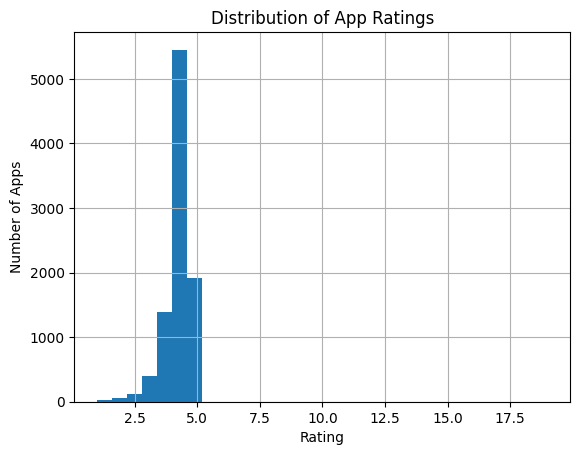

In [20]:
import matplotlib.pyplot as plt

df['Rating'].hist(bins=30)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

## 7.Conclusions

In this project, Exploratory Data Analysis was performed on the Google Play Store apps dataset to understand patterns in app ratings, categories, installs, and pricing. The analysis provided insights into how different factors influence app popularity and user engagement.

From the analysis, it was observed that most applications on the platform are free, while paid apps represent a much smaller portion of the market. Certain categories contain a significantly higher number of apps, indicating strong competition in those areas. Additionally, app ratings tend to cluster around higher values, suggesting that many apps receive generally positive user feedback.

The analysis also highlighted that only a small number of apps achieve extremely high install counts, while the majority of apps have relatively fewer installs. This indicates that popularity on the platform is concentrated among a limited set of applications.

Overall, the exploratory analysis helped in understanding the structure and characteristics of the dataset. These insights can be useful for further studies, such as building machine learning models to predict app success or user ratings based on various app features.